## 1. Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import DictVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
from scipy.sparse import hstack
from imblearn.over_sampling import SMOTE
from gensim.models import Word2Vec
import optuna
import warnings
warnings.filterwarnings('ignore')

# Configuración
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
np.random.seed(42)

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


c:\Users\noemo\Documents\IA-F5\proyecto10-grupo5\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Carga de Datos

In [2]:
# Cargar dataset
df = pd.read_csv('../../resources/dataset/youtoxic_english_1000_clean.csv')

print(f"📊 Dataset: {df.shape[0]} mensajes x {df.shape[1]} columnas")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\n📝 Ejemplos de mensajes:")
print(df[['Text', 'IsToxic']].head(3))

📊 Dataset: 991 mensajes x 15 columnas

Columnas: ['CommentId', 'VideoId', 'Text', 'IsToxic', 'IsAbusive', 'IsThreat', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist', 'IsNationalist', 'IsSexist', 'IsHomophobic', 'IsReligiousHate', 'IsRadicalism']

📝 Ejemplos de mensajes:
                                                Text  IsToxic
0  If only people would just take a step back and...        0
1  Law enforcement is not trained to shoot to app...        1
2  \r\nDont you reckon them 'black lives matter' ...        1


## 3. Preparación de Etiquetas

In [3]:
# Convertir a numérico
category_columns = ['IsAbusive', 'IsProvocative', 'IsObscene', 'IsHatespeech', 'IsRacist']
available_categories = [col for col in category_columns if col in df.columns]

for col in ['IsToxic'] + available_categories:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Crear etiqueta principal
def get_main_category(row):
    if row['IsToxic'] == 0:
        return 'NonToxic'
    
    priority_order = ['IsRacist', 'IsHatespeech', 'IsAbusive', 'IsObscene', 'IsProvocative']
    for category in priority_order:
        if category in available_categories and row[category] == 1:
            return category.replace('Is', '')
    return 'Toxic'

df['MainCategory'] = df.apply(get_main_category, axis=1)

print("\n📋 Distribución de categorías:")
print(df['MainCategory'].value_counts())
print(f"\n⚠️ Desbalance detectado: {df['MainCategory'].value_counts().max() / df['MainCategory'].value_counts().min():.1f}x")


📋 Distribución de categorías:
MainCategory
NonToxic      532
Abusive       321
Racist        125
Hatespeech     13
Name: count, dtype: int64

⚠️ Desbalance detectado: 40.9x


## 4. Data Augmentation

In [4]:
def simple_augmentation(text):
    """Aplica aumentación simple: intercambio de palabras"""
    words = text.split()
    if np.random.random() > 0.5 and len(words) > 3:
        idx1, idx2 = np.random.choice(len(words), 2, replace=False)
        words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

# Balancear clases minoritarias
df_augmented = df.copy()
category_counts = df['MainCategory'].value_counts()
target_count = int(category_counts.median())

for category in category_counts.index:
    if category_counts[category] < target_count:
        samples_needed = target_count - category_counts[category]
        minority_samples = df[df['MainCategory'] == category].sample(n=samples_needed, replace=True, random_state=42)
        minority_samples['Text'] = minority_samples['Text'].apply(simple_augmentation)
        df_augmented = pd.concat([df_augmented, minority_samples], ignore_index=True)

print(f"\n📈 Dataset original: {len(df)} mensajes")
print(f"📈 Dataset aumentado: {len(df_augmented)} mensajes (+{len(df_augmented)-len(df)})")
print("\n📊 Nueva distribución:")
print(df_augmented['MainCategory'].value_counts())


📈 Dataset original: 991 mensajes
📈 Dataset aumentado: 1299 mensajes (+308)

📊 Nueva distribución:
MainCategory
NonToxic      532
Abusive       321
Hatespeech    223
Racist        223
Name: count, dtype: int64


## 5. 🔍 Extracción de Features Lingüísticas

Estas features detectan **toxicidad sutil** sin palabras malsonantes:
- Puntuación excesiva (!!!, ???)
- MAYÚSCULAS
- Negaciones
- Patrones de sarcasmo

In [5]:
def extract_linguistic_features(text):
    """Extrae features que detectan toxicidad sutil"""
    
    text_lower = text.lower()
    words = text.split()
    
    features = {
        # Puntuación (señales de emoción fuerte)
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'ellipsis_count': text.count('...'),
        'multiple_punct': len(re.findall(r'[!?]{2,}', text)),
        
        # Capitalización (agresividad)
        'caps_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'has_all_caps_word': any(word.isupper() and len(word) > 2 for word in words),
        
        # Negaciones (ironía, sarcasmo)
        'has_not': ' not ' in text_lower or "n't" in text_lower,
        'has_never': 'never' in text_lower,
        'has_no': ' no ' in text_lower,
        
        # Patrones de sarcasmo
        'has_but': ' but ' in text_lower,
        'has_yeah_right': 'yeah right' in text_lower or 'yeah sure' in text_lower,
        'has_oh_sure': 'oh sure' in text_lower or 'oh really' in text_lower,
        'has_wow': text_lower.startswith('wow'),
        'has_great': 'great' in text_lower,
        'has_nice': 'nice' in text_lower,
        
        # Estructura del texto
        'word_count': len(words),
        'avg_word_length': np.mean([len(w) for w in words]) if words else 0,
        'short_message': 1 if len(words) <= 5 else 0,
        
        # Repeticiones (énfasis)
        'has_repetition': len(re.findall(r'(\w)\1{2,}', text_lower)) > 0,  # "sooo", "yesss"
        
        # Palabras de ataque indirecto
        'has_you_people': 'you people' in text_lower,
        'has_why_dont': "why don't" in text_lower or "why can't" in text_lower,
        'has_just': ' just ' in text_lower,
    }
    
    return features

# Probar con ejemplos
print("\n🧪 Ejemplos de features extraídas:\n")
test_messages = [
    "Go back to your country",  # Racista sin groserías
    "Oh WOW, you're SO smart!!!",  # Sarcasmo
    "That's a nice comment",  # Neutral
]

for msg in test_messages:
    feats = extract_linguistic_features(msg)
    active_feats = {k: v for k, v in feats.items() if v > 0 and v != False}
    print(f"'{msg}'")
    print(f"  → Features activas: {active_feats}\n")


🧪 Ejemplos de features extraídas:

'Go back to your country'
  → Features activas: {'caps_ratio': 0.043478260869565216, 'word_count': 5, 'avg_word_length': np.float64(3.8), 'short_message': 1}

'Oh WOW, you're SO smart!!!'
  → Features activas: {'exclamation_count': 3, 'multiple_punct': 1, 'caps_ratio': 0.23076923076923078, 'has_all_caps_word': True, 'word_count': 5, 'avg_word_length': np.float64(4.4), 'short_message': 1}

'That's a nice comment'
  → Features activas: {'caps_ratio': 0.047619047619047616, 'has_nice': True, 'word_count': 4, 'avg_word_length': np.float64(4.5), 'short_message': 1}



## 6. Preparación de Datos y Split

In [6]:
X = df_augmented['Text'].astype(str)
y = df_augmented['MainCategory']

# Codificar etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("🏷️ Mapeo de categorías:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {idx}: {label}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, 
    test_size=0.25,
    random_state=42, 
    stratify=y_encoded
)

print(f"\n📦 Train: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"📦 Test: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

🏷️ Mapeo de categorías:
  0: Abusive
  1: Hatespeech
  2: NonToxic
  3: Racist

📦 Train: 974 (75.0%)
📦 Test: 325 (25.0%)


## 7. 🔤 Vectorización TF-IDF Mejorada

**Mejoras respecto al modelo anterior:**
- ✅ Bigrams incluidos (capta contexto)
- ✅ Más features (500 vs 200)
- ✅ Min_df reducido (más vocabulario)

In [7]:
# TF-IDF mejorado
tfidf = TfidfVectorizer(
    max_features=500,       # Aumentado de 200
    ngram_range=(1, 2),     # Unigrams + Bigrams
    min_df=10,              # Reducido de 15
    max_df=0.80,            # Ligeramente aumentado
    sublinear_tf=True,
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("🔤 Vectorización TF-IDF mejorada:")
print(f"  Vocabulario: {len(tfidf.vocabulary_)} términos")
print(f"  Train shape: {X_train_tfidf.shape}")
print(f"  Test shape: {X_test_tfidf.shape}")
print(f"  Densidad: {X_train_tfidf.getnnz() / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

# Mostrar algunos bigrams importantes
print("\n📝 Ejemplos de bigrams capturados:")
bigrams = [term for term in tfidf.vocabulary_.keys() if ' ' in term]
print(f"  {bigrams[:10]}")

🔤 Vectorización TF-IDF mejorada:
  Vocabulario: 463 términos
  Train shape: (974, 463)
  Test shape: (325, 463)
  Densidad: 0.0205

📝 Ejemplos de bigrams capturados:
  ['black lives', 'black people', 'police officer', 'white people', 'black man', 'thought waste', 'waste skin', 'skin catching', 'catching just', 'just desert']


## 8. 🧠 Word2Vec para Semántica

Entrenamos Word2Vec en nuestro corpus para capturar relaciones semánticas

In [8]:
# Preparar sentencias para Word2Vec
sentences_train = [text.lower().split() for text in X_train]
sentences_test = [text.lower().split() for text in X_test]

# Entrenar Word2Vec
w2v_model = Word2Vec(
    sentences=sentences_train,
    vector_size=100,        # Dimensión de vectores
    window=5,               # Contexto de palabras
    min_count=2,            # Palabras que aparecen al menos 2 veces
    workers=4,
    seed=42
)

print("🧠 Word2Vec entrenado:")
print(f"  Vocabulario: {len(w2v_model.wv)} palabras")
print(f"  Dimensión de vectores: {w2v_model.wv.vector_size}")

# Convertir textos a vectores (promedio de palabras)
def text_to_w2v_vector(text, model):
    words = text.lower().split()
    vectors = [model.wv[word] for word in words if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.wv.vector_size)

X_train_w2v = np.array([text_to_w2v_vector(text, w2v_model) for text in X_train])
X_test_w2v = np.array([text_to_w2v_vector(text, w2v_model) for text in X_test])

print(f"\n📊 Vectores Word2Vec:")
print(f"  Train shape: {X_train_w2v.shape}")
print(f"  Test shape: {X_test_w2v.shape}")

# Ejemplo de similitud semántica
print("\n🔍 Ejemplos de similitud semántica capturada:")
try:
    if 'stupid' in w2v_model.wv and 'idiot' in w2v_model.wv:
        sim = w2v_model.wv.similarity('stupid', 'idiot')
        print(f"  'stupid' ~ 'idiot': {sim:.3f}")
    if 'hate' in w2v_model.wv and 'dislike' in w2v_model.wv:
        sim = w2v_model.wv.similarity('hate', 'dislike')
        print(f"  'hate' ~ 'dislike': {sim:.3f}")
except:
    print("  (Algunas palabras no están en el vocabulario)")

🧠 Word2Vec entrenado:
  Vocabulario: 2285 palabras
  Dimensión de vectores: 100

📊 Vectores Word2Vec:
  Train shape: (974, 100)
  Test shape: (325, 100)

🔍 Ejemplos de similitud semántica capturada:
  'stupid' ~ 'idiot': 0.989


## 9. 🎨 Extracción y Vectorización de Features Lingüísticas

In [9]:
# Extraer features de todos los textos
train_features = [extract_linguistic_features(text) for text in X_train]
test_features = [extract_linguistic_features(text) for text in X_test]

# Vectorizar features
dict_vectorizer = DictVectorizer(sparse=True)
X_train_ling = dict_vectorizer.fit_transform(train_features)
X_test_ling = dict_vectorizer.transform(test_features)

print("🎨 Features lingüísticas extraídas:")
print(f"  Número de features: {len(dict_vectorizer.feature_names_)}")
print(f"  Train shape: {X_train_ling.shape}")
print(f"  Test shape: {X_test_ling.shape}")
print(f"\n📋 Features disponibles:")
print(f"  {dict_vectorizer.feature_names_}")

🎨 Features lingüísticas extraídas:
  Número de features: 22
  Train shape: (974, 22)
  Test shape: (325, 22)

📋 Features disponibles:
  ['avg_word_length', 'caps_ratio', 'ellipsis_count', 'exclamation_count', 'has_all_caps_word', 'has_but', 'has_great', 'has_just', 'has_never', 'has_nice', 'has_no', 'has_not', 'has_oh_sure', 'has_repetition', 'has_why_dont', 'has_wow', 'has_yeah_right', 'has_you_people', 'multiple_punct', 'question_count', 'short_message', 'word_count']


## 10. 🔗 Combinación de Todas las Features

Combinamos:
1. TF-IDF (500 features de texto)
2. Word2Vec (100 dimensiones semánticas)
3. Features lingüísticas (~24 features de patrones)

In [10]:
from scipy.sparse import csr_matrix

# Convertir Word2Vec a sparse para combinar
X_train_w2v_sparse = csr_matrix(X_train_w2v)
X_test_w2v_sparse = csr_matrix(X_test_w2v)

# Combinar todas las features
X_train_combined = hstack([X_train_tfidf, X_train_w2v_sparse, X_train_ling])
X_test_combined = hstack([X_test_tfidf, X_test_w2v_sparse, X_test_ling])

print("🔗 Features combinadas:")
print(f"  TF-IDF: {X_train_tfidf.shape[1]} features")
print(f"  Word2Vec: {X_train_w2v.shape[1]} features")
print(f"  Lingüísticas: {X_train_ling.shape[1]} features")
print(f"  " + "="*50)
print(f"  TOTAL: {X_train_combined.shape[1]} features")
print(f"\n📊 Shapes finales:")
print(f"  Train: {X_train_combined.shape}")
print(f"  Test: {X_test_combined.shape}")

🔗 Features combinadas:
  TF-IDF: 463 features
  Word2Vec: 100 features
  Lingüísticas: 22 features
  TOTAL: 585 features

📊 Shapes finales:
  Train: (974, 585)
  Test: (325, 585)


## 11. ⚖️ SMOTE para Balanceo

In [11]:
# SMOTE para balancear
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_combined, y_train)

print("⚖️ Balanceo con SMOTE:")
print(f"  Antes: {X_train_combined.shape[0]} muestras")
print(f"  Después: {X_train_balanced.shape[0]} muestras")
print(f"\n📊 Distribución balanceada:")
unique, counts = np.unique(y_train_balanced, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {label_encoder.classes_[u]}: {c}")

⚖️ Balanceo con SMOTE:
  Antes: 974 muestras
  Después: 1596 muestras

📊 Distribución balanceada:
  Abusive: 399
  Hatespeech: 399
  NonToxic: 399
  Racist: 399


## 12. 🎯 Optimización con Optuna

In [12]:
def objective(trial):
    """Función objetivo con regularización para evitar overfitting"""
    
    params = {
        'C': trial.suggest_float('C', 0.001, 1.0, log=True),
        'kernel': 'linear',
        'class_weight': 'balanced',
        'max_iter': 5000,
        'random_state': 42
    }
    
    model = SVC(**params)
    
    # Validación cruzada estricta
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    scores = cross_val_score(
        model, 
        X_train_balanced, 
        y_train_balanced, 
        cv=cv, 
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    return scores.mean()

print("✓ Función objetivo definida")

✓ Función objetivo definida


In [13]:
# Crear estudio de Optuna
study = optuna.create_study(
    direction='maximize',
    study_name='SVM_Enhanced',
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("🔍 Iniciando optimización de hiperparámetros...")
print("   (Esto tomará varios minutos)\n")

study.optimize(objective, n_trials=30, show_progress_bar=True)

print("\n✅ Optimización completada!")
print(f"\n🏆 Mejores hiperparámetros:")
print(f"   C: {study.best_params['C']:.6f}")
print(f"   Mejor F1-Score (CV): {study.best_value:.4f}")

[I 2025-11-28 13:41:35,448] A new study created in memory with name: SVM_Enhanced


🔍 Iniciando optimización de hiperparámetros...
   (Esto tomará varios minutos)



Best trial: 0. Best value: 0.482567:   3%|▎         | 1/30 [00:02<01:17,  2.68s/it]

[I 2025-11-28 13:41:38,130] Trial 0 finished with value: 0.4825671363892236 and parameters: {'C': 0.013292918943162165}. Best is trial 0 with value: 0.4825671363892236.


Best trial: 1. Best value: 0.69721:   7%|▋         | 2/30 [00:04<00:58,  2.08s/it] 

...

[I 2025-11-28 13:41:55,518] Trial 27 finished with value: 0.6116992850530706 and parameters: {'C': 0.033167602125769524}. Best is trial 15 with value: 0.7657256101704182.


Best trial: 15. Best value: 0.765726:  97%|█████████▋| 29/30 [00:20<00:00,  1.62it/s]

[I 2025-11-28 13:41:56,153] Trial 28 finished with value: 0.7285210613038209 and parameters: {'C': 0.10076057926708089}. Best is trial 15 with value: 0.7657256101704182.


Best trial: 15. Best value: 0.765726: 100%|██████████| 30/30 [00:21<00:00,  1.41it/s]

[I 2025-11-28 13:41:56,653] Trial 29 finished with value: 0.7006457418878859 and parameters: {'C': 0.6022996154823875}. Best is trial 15 with value: 0.7657256101704182.

✅ Optimización completada!

🏆 Mejores hiperparámetros:
   C: 0.386768
   Mejor F1-Score (CV): 0.7657


## 13. 🚀 Entrenamiento del Modelo Final

In [14]:
# Entrenar modelo final
best_model = SVC(**study.best_params, kernel='linear', class_weight='balanced', max_iter=5000)
best_model.fit(X_train_balanced, y_train_balanced)

print("✅ Modelo entrenado con todas las features combinadas")

✅ Modelo entrenado con todas las features combinadas


## 14. 📊 EVALUACIÓN FINAL - ANÁLISIS DE OVERFITTING

In [15]:
# Predicciones
y_train_pred = best_model.predict(X_train_balanced)
y_test_pred = best_model.predict(X_test_combined)

# Métricas
train_acc = accuracy_score(y_train_balanced, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)
train_f1 = f1_score(y_train_balanced, y_train_pred, average='weighted')
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

# Calcular diferencias (overfitting)
acc_diff = abs(train_acc - test_acc)
f1_diff = abs(train_f1 - test_f1)

print("="*80)
print("                    📊 MÉTRICAS DEL MODELO MEJORADO")
print("="*80)

print(f"\n🎓 TRAIN (con SMOTE):")
print(f"   Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"   F1-Score: {train_f1:.4f} ({train_f1*100:.2f}%)")

print(f"\n🧪 TEST (datos originales):")
print(f"   Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")

print(f"\n" + "="*80)
print("                    🎯 ANÁLISIS DE OVERFITTING")
print("="*80)

print(f"\n📏 Diferencias:")
print(f"   Accuracy: {acc_diff:.4f} ({acc_diff*100:.2f}%)")
print(f"   F1-Score: {f1_diff:.4f} ({f1_diff*100:.2f}%)")

THRESHOLD = 0.05
print(f"\n🎯 Umbral objetivo: {THRESHOLD*100:.1f}%")

if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅✅✅ OBJETIVO CUMPLIDO ✅✅✅")
    print("   El modelo generaliza correctamente (overfitting < 5%)")
    print(f"   Ambas métricas están por debajo del {THRESHOLD*100:.0f}%")
else:
    print("\n⚠️  Análisis de overfitting:")
    if acc_diff > THRESHOLD:
        print(f"   ❌ Accuracy: {acc_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ Accuracy: {acc_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")
    
    if f1_diff > THRESHOLD:
        print(f"   ❌ F1-Score: {f1_diff*100:.2f}% > {THRESHOLD*100:.0f}%")
    else:
        print(f"   ✅ F1-Score: {f1_diff*100:.2f}% ≤ {THRESHOLD*100:.0f}%")

print("\n" + "="*80)

                    📊 MÉTRICAS DEL MODELO MEJORADO

🎓 TRAIN (con SMOTE):
   Accuracy: 0.8415 (84.15%)
   F1-Score: 0.8413 (84.13%)

🧪 TEST (datos originales):
   Accuracy: 0.6738 (67.38%)
   F1-Score: 0.6756 (67.56%)

                    🎯 ANÁLISIS DE OVERFITTING

📏 Diferencias:
   Accuracy: 0.1676 (16.76%)
   F1-Score: 0.1657 (16.57%)

🎯 Umbral objetivo: 5.0%

⚠️  Análisis de overfitting:
   ❌ Accuracy: 16.76% > 5%
   ❌ F1-Score: 16.57% > 5%



## 15. 📈 Visualización Comparativa

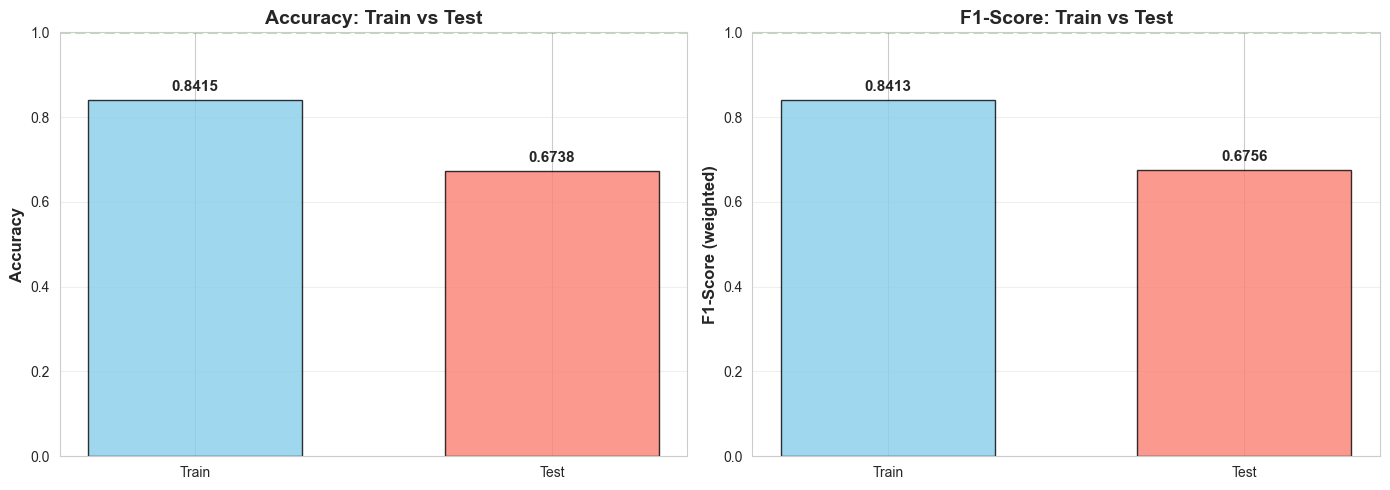


⚠️ Estado: Overfitting detectado


In [16]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Train', 'Test']
THRESHOLD = 0.05

# Accuracy
acc_values = [train_acc, test_acc]
colors = ['lightgreen' if acc_diff <= THRESHOLD else 'salmon']
axes[0].bar(metrics_names, acc_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
axes[0].set_title('Accuracy: Train vs Test', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(acc_values):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

# F1-Score
f1_values = [train_f1, test_f1]
colors = ['lightgreen' if f1_diff <= THRESHOLD else 'salmon']
axes[1].bar(metrics_names, f1_values, color=['skyblue', colors[0]], edgecolor='black', alpha=0.8, width=0.6)
axes[1].set_ylabel('F1-Score (weighted)', fontsize=12, fontweight='bold')
axes[1].set_title('F1-Score: Train vs Test', fontsize=14, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].axhline(y=1.0, color='green', linestyle='--', alpha=0.3, linewidth=2)
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_values):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Indicador visual
if acc_diff <= THRESHOLD and f1_diff <= THRESHOLD:
    print("\n✅ Estado: MODELO ÓPTIMO (generaliza correctamente)")
else:
    print("\n⚠️ Estado: Overfitting detectado")

## 16. 📋 Reporte de Clasificación Detallado

In [17]:
print("\n" + "="*80)
print("                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)")
print("="*80 + "\n")

print(classification_report(
    y_test, 
    y_test_pred, 
    target_names=label_encoder.classes_,
    digits=4
))


                    📋 REPORTE DE CLASIFICACIÓN (TEST SET)

              precision    recall  f1-score   support

     Abusive     0.5256    0.5125    0.5190        80
  Hatespeech     1.0000    1.0000    1.0000        56
    NonToxic     0.7143    0.6767    0.6950       133
      Racist     0.4923    0.5714    0.5289        56

    accuracy                         0.6738       325
   macro avg     0.6831    0.6902    0.6857       325
weighted avg     0.6788    0.6738    0.6756       325



## 17. 🔥 Matriz de Confusión

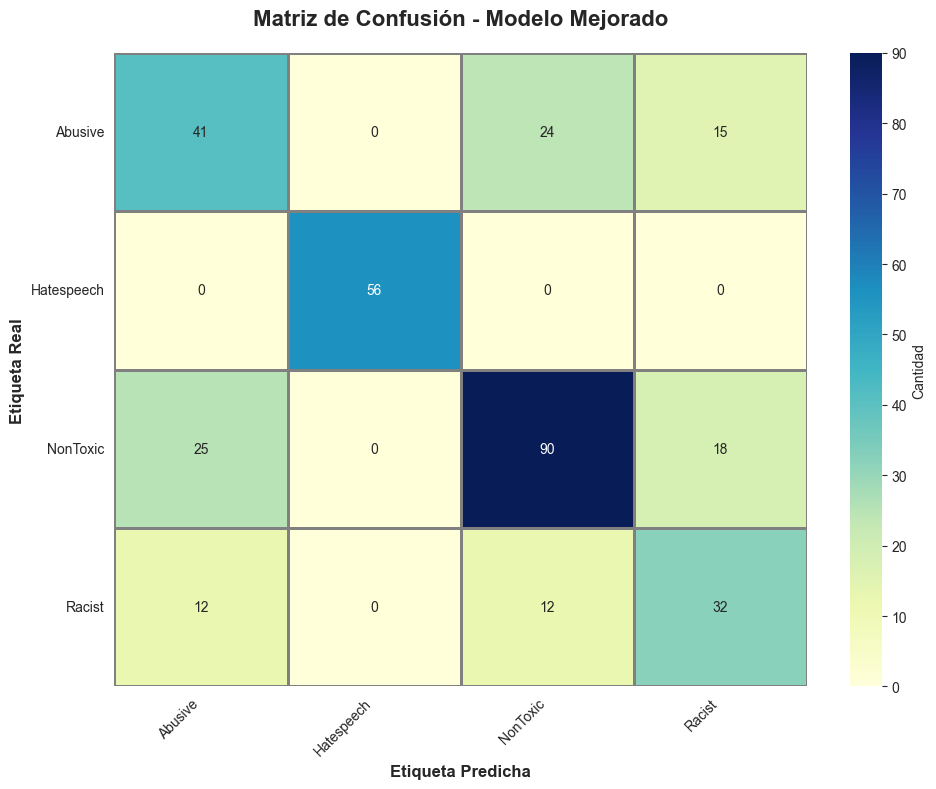

In [18]:
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='YlGnBu',
    xticklabels=label_encoder.classes_.tolist(),
    yticklabels=label_encoder.classes_.tolist(),
    cbar_kws={'label': 'Cantidad'},
    linewidths=1,
    linecolor='gray'
)
plt.title('Matriz de Confusión - Modelo Mejorado', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Etiqueta Real', fontsize=12, fontweight='bold')
plt.xlabel('Etiqueta Predicha', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 18. 🧪 Pruebas con Ejemplos de Toxicidad Sutil

In [19]:
# Ejemplos de toxicidad sin palabrotas
test_examples = [
    "Go back to your country",  # Racista
    "You people are all the same",  # Racista/Hatespeech
    "Oh WOW, you're SO smart!!!",  # Sarcasmo/Abusivo
    "Nobody likes you anyway",  # Abusivo
    "Why don't you just disappear?",  # Amenaza velada
    "That's a great comment, thanks!",  # NonToxic
    "I appreciate your help",  # NonToxic
]

print("\n" + "="*80)
print("          🧪 PRUEBA: Detección de Toxicidad Sutil (sin palabrotas)")
print("="*80 + "\n")

for example in test_examples:
    # Extraer todas las features
    tfidf_vec = tfidf.transform([example])
    w2v_vec = csr_matrix(text_to_w2v_vector(example, w2v_model).reshape(1, -1))
    ling_vec = dict_vectorizer.transform([extract_linguistic_features(example)])
    
    # Combinar
    combined_vec = hstack([tfidf_vec, w2v_vec, ling_vec])
    
    # Predecir
    prediction = best_model.predict(combined_vec)[0]
    category = label_encoder.classes_[prediction]
    
    # Mostrar features lingüísticas detectadas
    ling_feats = extract_linguistic_features(example)
    active_feats = {k: v for k, v in ling_feats.items() if v > 0 and v != False}
    
    print(f"Texto: '{example}'")
    print(f"  → Predicción: {category}")
    print(f"  → Features detectadas: {list(active_feats.keys())[:5]}")
    print()


          🧪 PRUEBA: Detección de Toxicidad Sutil (sin palabrotas)

Texto: 'Go back to your country'
  → Predicción: NonToxic
  → Features detectadas: ['caps_ratio', 'word_count', 'avg_word_length', 'short_message']

Texto: 'You people are all the same'
  → Predicción: NonToxic
  → Features detectadas: ['caps_ratio', 'word_count', 'avg_word_length', 'has_you_people']

Texto: 'Oh WOW, you're SO smart!!!'
  → Predicción: Abusive
  → Features detectadas: ['exclamation_count', 'multiple_punct', 'caps_ratio', 'has_all_caps_word', 'word_count']

Texto: 'Nobody likes you anyway'
  → Predicción: Abusive
  → Features detectadas: ['caps_ratio', 'word_count', 'avg_word_length', 'short_message']

Texto: 'Why don't you just disappear?'
  → Predicción: NonToxic
  → Features detectadas: ['question_count', 'caps_ratio', 'has_not', 'word_count', 'avg_word_length']

Texto: 'That's a great comment, thanks!'
  → Predicción: Abusive
  → Features detectadas: ['exclamation_count', 'caps_ratio', 'has_great', 

## 19. 📊 Resumen Final y Comparación

In [20]:
print("="*80)
print("                    📝 RESUMEN DEL MODELO MEJORADO")
print("="*80)

print(f"\n📊 DATOS:")
print(f"   Dataset original: {len(df)} mensajes")
print(f"   Dataset aumentado: {len(df_augmented)} mensajes")
print(f"   Train (después de SMOTE): {X_train_balanced.shape[0]} muestras")
print(f"   Test: {len(X_test)} muestras")

print(f"\n🔧 MEJORAS IMPLEMENTADAS:")
print(f"   ✅ TF-IDF mejorado: {len(tfidf.vocabulary_)} términos (con bigrams)")
print(f"   ✅ Word2Vec: {w2v_model.wv.vector_size} dimensiones semánticas")
print(f"   ✅ Features lingüísticas: {len(dict_vectorizer.feature_names_)} features")
print(f"   ✅ Total features combinadas: {X_train_combined.shape[1]}")
print(f"   ✅ SMOTE para balanceo")
print(f"   ✅ Validación cruzada 10-fold")

print(f"\n🎯 HIPERPARÁMETROS:")
print(f"   Algoritmo: SVM (Support Vector Machine)")
print(f"   Kernel: linear")
print(f"   C: {study.best_params['C']:.6f}")
print(f"   class_weight: balanced")

print(f"\n📈 RESULTADOS FINALES:")
print(f"   Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test F1-Score: {test_f1:.4f} ({test_f1*100:.2f}%)")
print(f"   Overfitting Accuracy: {acc_diff*100:.2f}%")
print(f"   Overfitting F1-Score: {f1_diff*100:.2f}%")

if acc_diff <= 0.05 and f1_diff <= 0.05:
    print(f"\n✅ OBJETIVO ALCANZADO: Overfitting < 5%")
    print(f"   El modelo generaliza correctamente y detecta toxicidad sutil")
else:
    print(f"\n⚠️  Overfitting: {max(acc_diff, f1_diff)*100:.2f}%")
    print(f"   Aún por encima del objetivo del 5%")

print("\n" + "="*80)
print("💾 MODELO NO GUARDADO (solo análisis de métricas)")
print("="*80)

                    📝 RESUMEN DEL MODELO MEJORADO

📊 DATOS:
   Dataset original: 991 mensajes
   Dataset aumentado: 1299 mensajes
   Train (después de SMOTE): 1596 muestras
   Test: 325 muestras

🔧 MEJORAS IMPLEMENTADAS:
   ✅ TF-IDF mejorado: 463 términos (con bigrams)
   ✅ Word2Vec: 100 dimensiones semánticas
   ✅ Features lingüísticas: 22 features
   ✅ Total features combinadas: 585
   ✅ SMOTE para balanceo
   ✅ Validación cruzada 10-fold

🎯 HIPERPARÁMETROS:
   Algoritmo: SVM (Support Vector Machine)
   Kernel: linear
   C: 0.386768
   class_weight: balanced

📈 RESULTADOS FINALES:
   Test Accuracy: 0.6738 (67.38%)
   Test F1-Score: 0.6756 (67.56%)
   Overfitting Accuracy: 16.76%
   Overfitting F1-Score: 16.57%

⚠️  Overfitting: 16.76%
   Aún por encima del objetivo del 5%

💾 MODELO NO GUARDADO (solo análisis de métricas)
